<p style="align: center;"><img align=center src="https://drive.google.com/uc?export=view&id=1I8kDikouqpH4hf7JBiSYAeNT2IO52T-T" width=600 height=480/></p>
<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

<h3 style="text-align: center;"><b>Домашнее задание. Generative adversarial networks</b></h3>


В этом домашнем задании вы обучите GAN генерировать лица людей и посмотрите на то, как можно оценивать качество генерации

In [1]:
import os
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
import torchvision.transforms as tt
import torch
import torch.nn as nn
import cv2
from tqdm.notebook import tqdm
from torchvision.utils import save_image
from torchvision.utils import make_grid
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

sns.set(style='darkgrid', font_scale=1.2)

device = (
    torch.device('mps') if torch.backends.mps.is_available() else
    torch.device('cuda') if torch.cuda.is_available() else
    torch.device('cpu')
)
device

device(type='cuda')

## Часть 1. Подготовка данных (1 балл)

В качестве обучающей выборки возьмем часть датасета [Flickr Faces](https://github.com/NVlabs/ffhq-dataset), который содержит изображения лиц людей в высоком разрешении (1024х1024). Оригинальный датасет очень большой, поэтому мы возьмем его часть. Скачать датасет можно [здесь](https://www.kaggle.com/datasets/tommykamaz/faces-dataset-small?resource=download-directory) и  [здесь](https://drive.google.com/file/d/1inyvLrN5wKBGCxQ4znMKBc64uL4uP_2x/view?usp=drive_link)

Давайте загрузим наши изображения. Напишите функцию, которая строит DataLoader для изображений, при этом меняя их размер до нужного значения (размер 1024 слишком большой, поэтому мы рекомендуем взять размер 128 либо немного больше)

In [2]:
try:
    import kagglehub
    DATA_ROOT = kagglehub.dataset_download("jessicali9530/lfw-dataset")
    DATA_DIR  = os.path.join(DATA_ROOT, "lfw-deepfunneled", "lfw-deepfunneled")
except Exception as e:
    DATA_DIR = "./faces"
    print(f"kagglehub не сработал ({e}); используем локальный путь: {DATA_DIR}")

print(f"Папка с данными: {DATA_DIR}")


def get_dataloader(image_size, batch_size):
  """
  Builds dataloader for training data.
  Use tt.Compose and tt.Resize for transformations
  :param image_size: height and wdith of the image
  :param batch_size: batch_size of the dataloader
  :returns: DataLoader object
  """
  transform = tt.Compose([
      tt.Resize((image_size, image_size)),
      tt.CenterCrop(image_size),
      tt.ToTensor(),
      # нормализация
      tt.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
  ])
  dataset = ImageFolder(root=DATA_DIR, transform=transform)
  loader  = DataLoader(dataset, batch_size=batch_size, shuffle=True,
                       num_workers=0, pin_memory=False, drop_last=True)
  return loader

Using Colab cache for faster access to the 'lfw-dataset' dataset.
Папка с данными: /kaggle/input/lfw-dataset/lfw-deepfunneled/lfw-deepfunneled


Батчей в эпохе: 206
Объектов всего: 13233


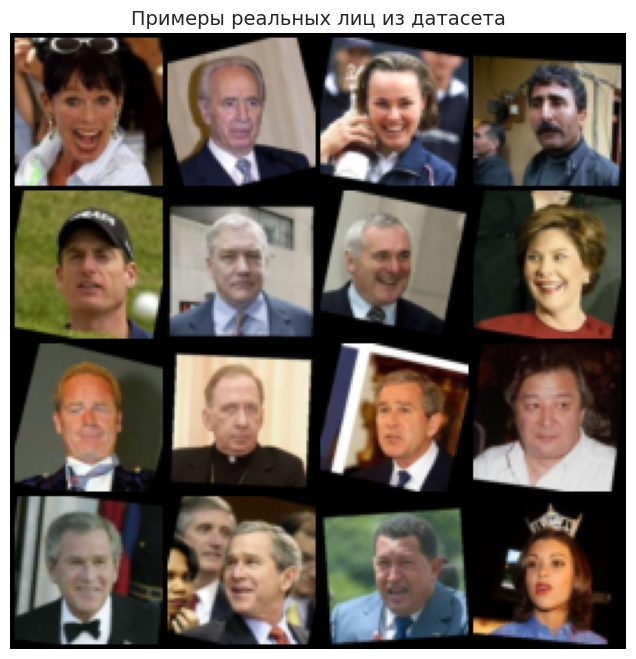

In [3]:
image_size = 64
batch_size = 64

loader = get_dataloader(image_size, batch_size)
print(f"Батчей в эпохе: {len(loader)}")
print(f"Объектов всего: {len(loader.dataset)}")


real_batch = next(iter(loader))[0][:16]
imgs_show  = real_batch * 0.5 + 0.5  # денормализация

grid = make_grid(imgs_show, nrow=4, padding=2)
plt.figure(figsize=(8, 8))
plt.imshow(grid.permute(1, 2, 0).numpy())
plt.axis('off')
plt.title("Примеры реальных лиц из датасета", fontsize=14)
plt.show()

## Часть 2. Построение и обучение модели (4 балла)

Сконструируйте генератор и дискриминатор. Помните, что:
* дискриминатор принимает на вход изображение (тензор размера `3 x image_size x image_size`) и выдает вероятность того, что изображение настоящее (тензор размера 1)

* генератор принимает на вход тензор шумов размера `latent_size x 1 x 1` и генерирует изображение размера `3 x image_size x image_size`

In [4]:
def weights_init(m):
    """Инициализация как в оригинальной DCGAN: conv — N(0, 0.02), BN — N(1, 0.02)."""
    name = m.__class__.__name__
    if 'Conv' in name:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif 'BatchNorm' in name:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)


class Discriminator(nn.Module):
    """DCGAN-дискриминатор: (3, 64, 64) → вероятность реальности (1,)."""
    def __init__(self, ndf=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, ndf, 4, 2, 1, bias=False), nn.LeakyReLU(0.2, True),
            nn.Conv2d(ndf, ndf*2, 4, 2, 1, bias=False), nn.BatchNorm2d(ndf*2), nn.LeakyReLU(0.2, True),
            nn.Conv2d(ndf*2 ndf*4, 4, 2, 1, bias=False), nn.BatchNorm2d(ndf*4), nn.LeakyReLU(0.2, True),
            nn.Conv2d(ndf*4 ndf*8, 4, 2, 1, bias=False), nn.BatchNorm2d(ndf*8), nn.LeakyReLU(0.2, True),
            nn.Conv2d(ndf*8, 1, 4, 1, 0, bias=False), nn.Sigmoid(),
        )

    def forward(self, x):
        return self.net(x).view(-1)


discriminator = Discriminator().to(device)
discriminator.apply(weights_init)

# проверим, что размерности сходятся
with torch.no_grad():
    dummy = torch.randn(2, 3, image_size, image_size, device=device)
    print(f"Discriminator: {tuple(dummy.shape)} → {tuple(discriminator(dummy).shape)}")
print(f"Параметров в Discriminator: {sum(p.numel() for p in discriminator.parameters()):,}")

Discriminator: (2, 3, 64, 64) → (2,)
Параметров в Discriminator: 2,765,568


In [5]:
latent_size = 100  # размерность шумового вектора


class Generator(nn.Module):
    """DCGAN-генератор: (latent_size, 1, 1) → (3, 64, 64)."""
    def __init__(self, latent_size, ngf=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(latent_size, ngf*8, 4, 1, 0, bias=False), nn.BatchNorm2d(ngf*8), nn.ReLU(True),
            nn.ConvTranspose2d(ngf*8,       ngf*4, 4, 2, 1, bias=False), nn.BatchNorm2d(ngf*4), nn.ReLU(True),
            nn.ConvTranspose2d(ngf*4,       ngf*2, 4, 2, 1, bias=False), nn.BatchNorm2d(ngf*2), nn.ReLU(True),
            nn.ConvTranspose2d(ngf*2,       ngf,   4, 2, 1, bias=False), nn.BatchNorm2d(ngf),   nn.ReLU(True),
            nn.ConvTranspose2d(ngf,         3,     4, 2, 1, bias=False), nn.Tanh(),
        )

    def forward(self, z):
        return self.net(z)


generator = Generator(latent_size).to(device)
generator.apply(weights_init)

with torch.no_grad():
    dummy_z = torch.randn(2, latent_size, 1, 1, device=device)
    print(f"Generator: {tuple(dummy_z.shape)} → {tuple(generator(dummy_z).shape)}")
print(f"Параметров в Generator: {sum(p.numel() for p in generator.parameters()):,}")

Generator: (2, 100, 1, 1) → (2, 3, 64, 64)
Параметров в Generator: 3,576,704


Перейдем теперь к обучению нашего GANа. Алгоритм обучения следующий:
1. Учим дискриминатор:
  * берем реальные изображения и присваиваем им метку 1
  * генерируем изображения генератором и присваиваем им метку 0
  * обучаем классификатор на два класса

2. Учим генератор:
  * генерируем изображения генератором и присваиваем им метку 0
  * предсказываем дискриминаторором, реальное это изображение или нет


В качестве функции потерь берем бинарную кросс-энтропию

In [6]:
lr = 0.0002

model = {
    "discriminator": discriminator,
    "generator": generator
}

criterion = {
    "discriminator": nn.BCELoss(),
    "generator": nn.BCELoss(),
}

 Эпоха    D_loss    G_loss
------------------------------
     1    0.7845   12.1381
     2    0.4992    5.8072
     3    0.6174    5.4380
     4    0.5918    4.8050
     5    0.5991    4.4330
     6    0.6251    4.0414
     7    0.6064    3.8884
     8    0.5853    3.8825
     9    0.5931    3.6697
    10    0.5625    3.6244


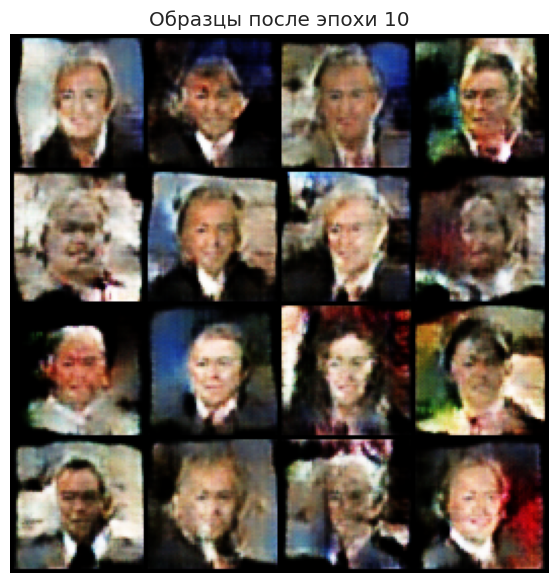

    11    0.6165    3.4700
    12    0.6803    3.2899
    13    0.6232    3.1250
    14    0.6748    3.0659
    15    0.6811    3.0020
    16    0.7242    2.9016
    17    0.6650    2.8238
    18    0.7124    2.8804
    19    0.6455    2.7668
    20    0.7354    2.7716


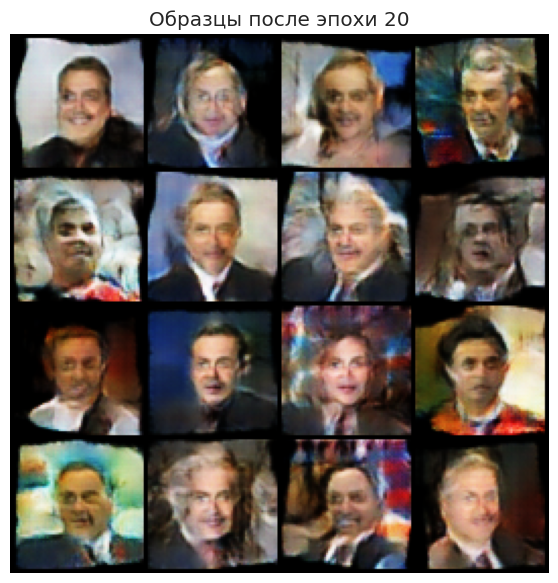

    21    0.7252    2.7647
    22    0.6951    2.7420
    23    0.6472    2.6552
    24    0.6022    2.7108
    25    0.6812    2.7775
    26    0.6766    2.7063
    27    0.6451    2.7119
    28    0.7342    2.6620
    29    0.6286    2.6475
    30    0.6077    2.7365


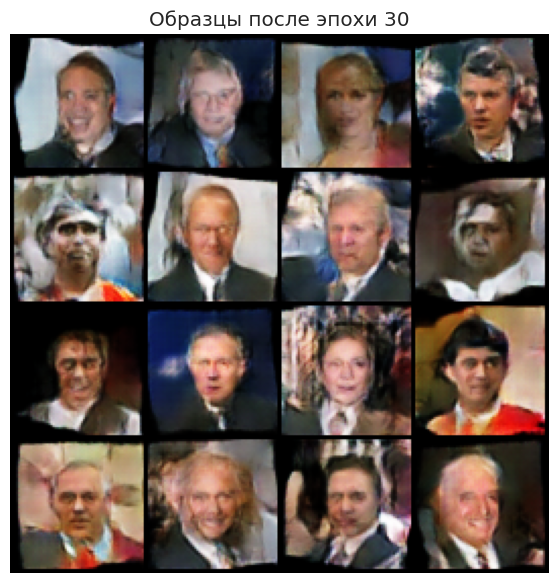

    31    0.5898    2.7378
    32    0.7084    2.7451
    33    0.6165    2.6880
    34    0.5957    2.6917
    35    0.5314    2.8545
    36    0.5675    2.8553
    37    0.5846    2.8339
    38    0.5281    2.8812
    39    0.4806    2.9669
    40    0.5685    2.9773


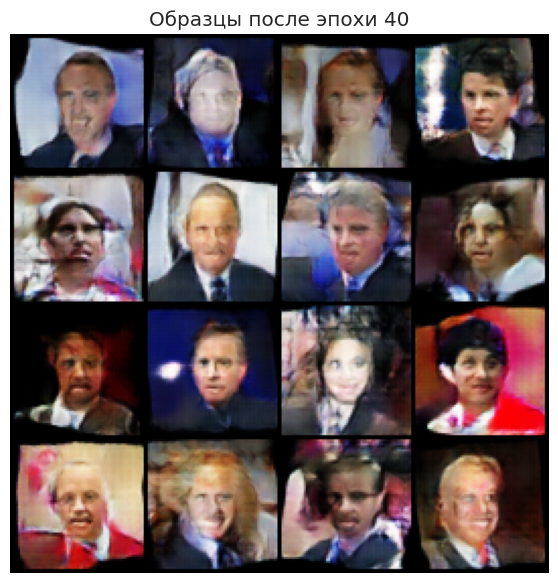

    41    0.3755    2.9985
    42    0.5224    3.0588
    43    0.5077    3.0679
    44    0.5532    3.0497
    45    0.3543    3.1691
    46    0.4897    3.1725
    47    0.4666    3.1835
    48    0.4223    3.2785
    49    0.4305    3.2717
    50    0.3886    3.2331


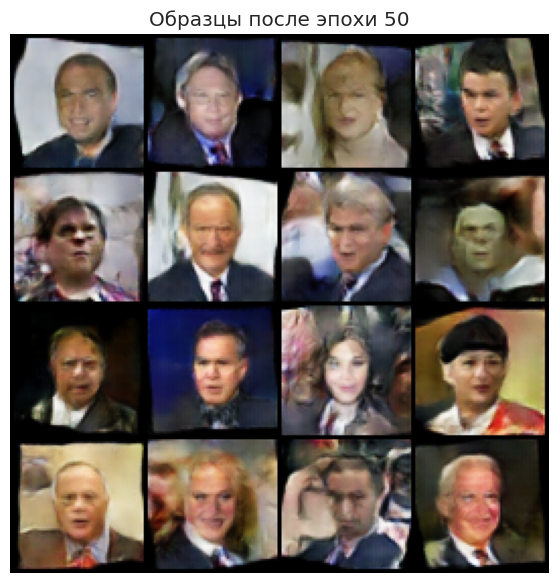

In [7]:
def fit(model, criterion, epochs, lr):
    """Тренируем GAN: чередуем шаги для D и G на каждой итерации."""
    D = model['discriminator']
    G = model['generator']

    opt_D = torch.optim.Adam(D.parameters(), lr=lr, betas=(0.5, 0.999))
    opt_G = torch.optim.Adam(G.parameters(), lr=lr, betas=(0.5, 0.999))

    d_losses, g_losses = [], []
    fixed_noise = torch.randn(16, latent_size, 1, 1, device=device)

    print(f"{'Эпоха':>6}  {'D_loss':>8}  {'G_loss':>8}")
    print("-" * 30)

    for epoch in range(1, epochs + 1):
        D.train(); G.train()
        ep_d, ep_g, n = 0.0, 0.0, 0

        for real_imgs, _ in loader:
            real_imgs = real_imgs.to(device)
            bs = real_imgs.size(0)

            # дискриминатор
            opt_D.zero_grad()
            # реальные
            loss_real = criterion['discriminator'](D(real_imgs), torch.ones(bs,  device=device))
            # фейковые
            noise     = torch.randn(bs, latent_size, 1, 1, device=device)
            fake_imgs = G(noise).detach()
            loss_fake = criterion['discriminator'](D(fake_imgs), torch.zeros(bs, device=device))
            loss_D    = loss_real + loss_fake
            loss_D.backward()
            opt_D.step()

            # генератор
            opt_G.zero_grad()
            noise = torch.randn(bs, latent_size, 1, 1, device=device)
            fake_imgs = G(noise)
            loss_G = criterion['generator'](D(fake_imgs), torch.ones(bs, device=device))
            loss_G.backward()
            opt_G.step()

            ep_d += loss_D.item(); ep_g += loss_G.item(); n += 1

        d_losses.append(ep_d / n)
        g_losses.append(ep_g / n)
        print(f"{epoch:>6}  {d_losses[-1]:>8.4f}  {g_losses[-1]:>8.4f}")

        if epoch % 10 == 0 or epoch == epochs:
            G.eval()
            with torch.no_grad():
                sample = G(fixed_noise).cpu() * 0.5 + 0.5
            grid = make_grid(sample, nrow=4, padding=2)
            plt.figure(figsize=(7, 7))
            plt.imshow(grid.permute(1, 2, 0).numpy().clip(0, 1))
            plt.axis('off')
            plt.title(f"Образцы после эпохи {epoch}")
            plt.show()

    return d_losses, g_losses


epochs = 50
d_losses, g_losses = fit(model, criterion, epochs=epochs, lr=lr)

Постройте графики лосса для генератора и дискриминатора. Что вы можете сказать про эти графики?

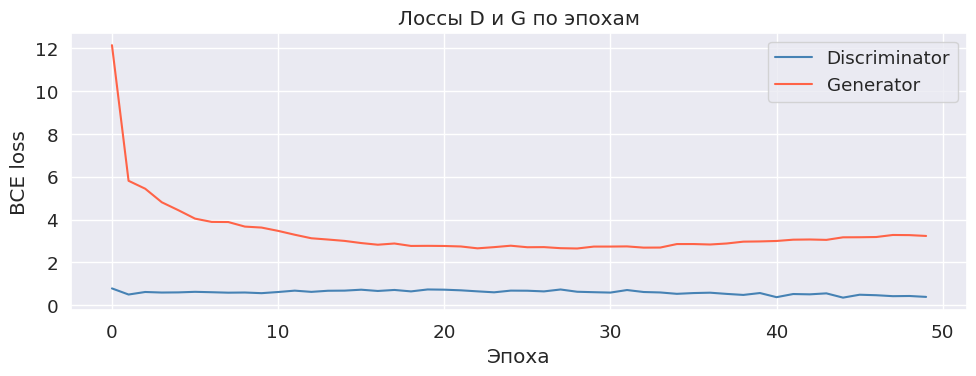

In [13]:
plt.figure(figsize=(10, 4))
plt.plot(d_losses, label='Discriminator', color='steelblue')
plt.plot(g_losses, label='Generator',     color='tomato')
plt.xlabel('Эпоха'); plt.ylabel('BCE loss')
plt.title('Лоссы D и G по эпохам')
plt.legend(); plt.tight_layout(); plt.show()

В начале D быстро отделяет реальное от шума → его loss низкий, у G — высокий.
 По мере обучения G учится обманывать D — кривые сходятся к равновесию.
Идеал для GAN: D_loss ≈ ln(2) ≈ 0.693 (D угадывает с p=50%).
Резкие скачки — норма для GAN, обучение нестабильно по своей природе.

## Часть 3. Генерация изображений

Теперь давайте оценим качество получившихся изображений. Напишите функцию, которая выводит изображения, сгенерированные нашим генератором

In [9]:
n_images = 4

fixed_latent = torch.randn(n_images, latent_size, 1, 1, device=device)
fake_images  = model["generator"](fixed_latent)

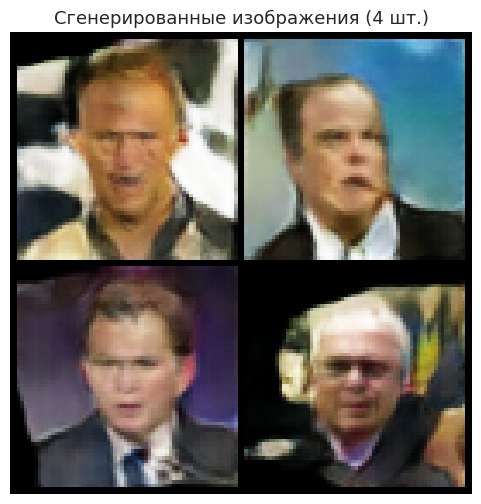

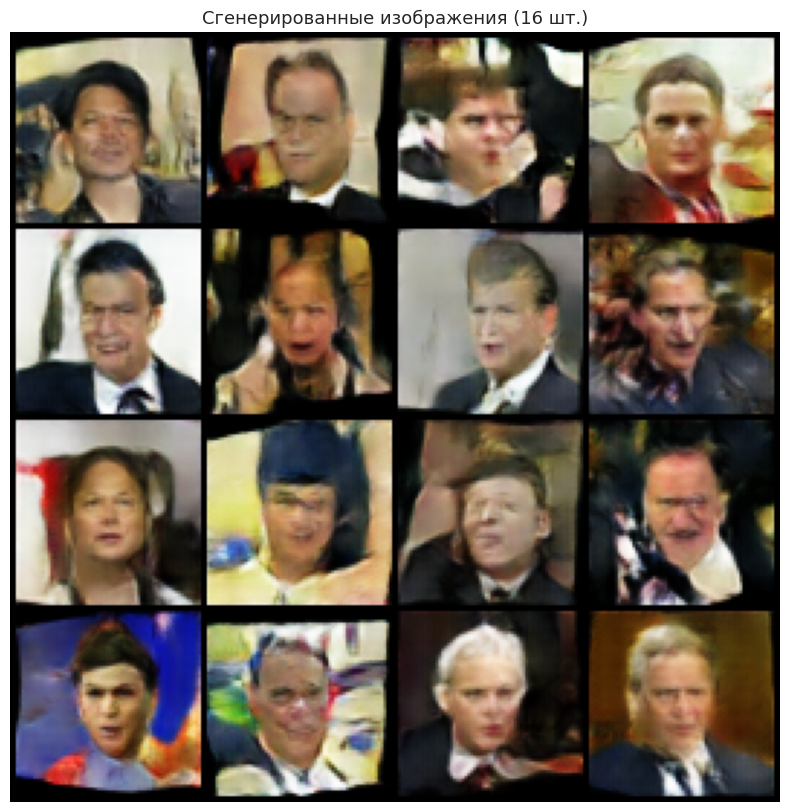

In [10]:
def show_images(generated):
    """Выводит сгенерированные изображения единой сеткой."""
    imgs = generated.detach().cpu() * 0.5 + 0.5     # денормализация
    imgs = imgs.clamp(0, 1)
    n = imgs.size(0)
    nrow = int(np.ceil(np.sqrt(n)))
    grid = make_grid(imgs, nrow=nrow, padding=2)
    plt.figure(figsize=(2 * nrow + 2, 2 * nrow + 2))
    plt.imshow(grid.permute(1, 2, 0).numpy())
    plt.axis('off')
    plt.title(f"Сгенерированные изображения ({n} шт.)", fontsize=13)
    plt.show()


show_images(fake_images)

# 16 штук
more_latent = torch.randn(16, latent_size, 1, 1, device=device)
with torch.no_grad():
    show_images(model['generator'](more_latent))

Как вам качество получившихся изображений?

## Часть 4. Leave-one-out-1-NN classifier accuracy (5 баллов)

### 4.1. Подсчет accuracy (3 балл)

Не всегда бывает удобно оценивать качество сгенерированных картинок глазами. В качестве альтернативы вам предлагается реализовать следующий подход:
  * Сгенерировать столько же фейковых изображений, сколько есть настоящих в обучающей выборке. Присвоить фейковым метку класса 0, настоящим – 1.
  * Построить leave-one-out оценку: обучить 1NN Classifier (`sklearn.neighbors.KNeighborsClassifier(n_neighbors=1)`) предсказывать класс на всех объектах, кроме одного, проверить качество (accuracy) на оставшемся объекте. В этом вам поможет `sklearn.model_selection.LeaveOneOut`

Матрица признаков: (600, 12288),  меток: (600,)


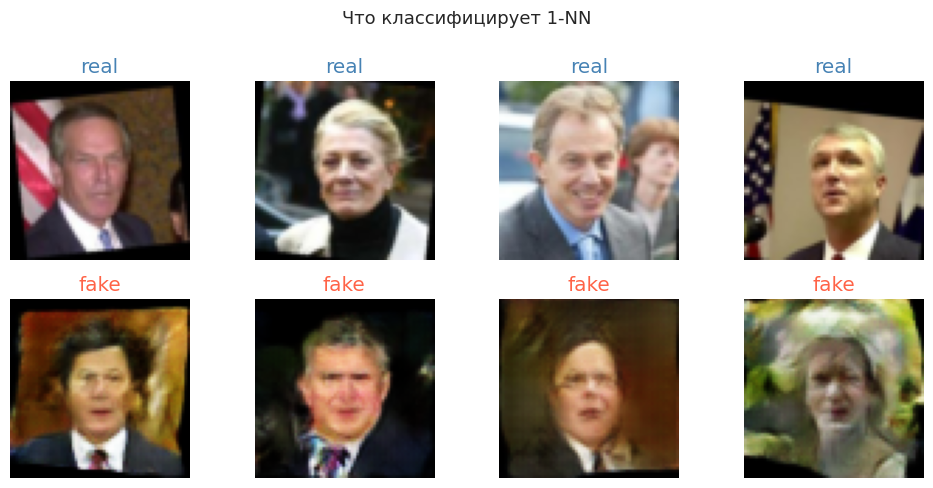


LOO accuracy: 0.5967  (59.7%)
Идеал : 0.50
Худший случай: 1.00


In [14]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import LeaveOneOut, cross_val_score
EVAL_N = 300

# реальные
eval_loader = DataLoader(loader.dataset, batch_size=EVAL_N, shuffle=True)
real_batch  = next(iter(eval_loader))[0]

# фейки
model['generator'].eval()
with torch.no_grad():
    noise      = torch.randn(EVAL_N, latent_size, 1, 1, device=device)
    fake_batch = model['generator'](noise).cpu()

# плоские векторы
real_flat = real_batch.view(EVAL_N, -1).numpy()
fake_flat = fake_batch.view(EVAL_N, -1).numpy()

X = np.vstack([real_flat, fake_flat])
y = np.array([1] * EVAL_N + [0] * EVAL_N)

print(f"Матрица признаков: {X.shape},  меток: {y.shape}")

fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for i in range(4):
    axes[0, i].imshow((real_batch[i] * 0.5 + 0.5).permute(1, 2, 0).numpy().clip(0, 1))
    axes[0, i].axis('off')
    axes[0, i].set_title("real", color='steelblue')
    axes[1, i].imshow((fake_batch[i] * 0.5 + 0.5).permute(1, 2, 0).numpy().clip(0, 1))
    axes[1, i].axis('off')
    axes[1, i].set_title("fake", color='tomato')
plt.suptitle("Что классифицирует 1-NN", fontsize=13)
plt.tight_layout(); plt.show()

knn = KNeighborsClassifier(n_neighbors=1)
loo = LeaveOneOut()
scores = cross_val_score(knn, X, y, cv=loo, scoring='accuracy', n_jobs=-1)
loo_acc = scores.mean()

print(f"\nLOO accuracy: {loo_acc:.4f}  ({loo_acc * 100:.1f}%)")
print(f"Идеал : 0.50")
print(f"Худший случай: 1.00")

Что вы можете сказать о получившемся результате? Какой accuracy мы хотели бы получить и почему?

**Ответ:** хотим получить accuracy около **0.5** — это значит, что 1-NN классификатор не может отличить реальные изображения от сгенерированных по близости в пространстве пикселей. Если accuracy около 1.0 — генератор слабый: его выход тривиально отличается от настоящих лиц. Если accuracy <0.5 — это тоже подозрительно: обычно говорит о том, что данные сильно сгруппированы (например, mode collapse приводит к тому, что фейки лежат внутри облака реальных, и 1-NN путается).

### 4.2. Визуализация распределений (2 балл)

Давайте посмотрим на то, насколько похожи распределения настоящих и фейковых изображений. Для этого воспользуйтесь методом, снижающим размерность (к примеру, TSNE) и изобразите на графике разным цветом точки, соответствующие реальным и сгенерированным изображенияи

t-SNE на 400 объектах размерности 12288...
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 400 samples in 0.002s...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


[t-SNE] Computed neighbors for 400 samples in 0.260s...
[t-SNE] Computed conditional probabilities for sample 400 / 400
[t-SNE] Mean sigma: 17.772805
[t-SNE] KL divergence after 250 iterations with early exaggeration: 66.981384
[t-SNE] KL divergence after 1000 iterations: 1.213611


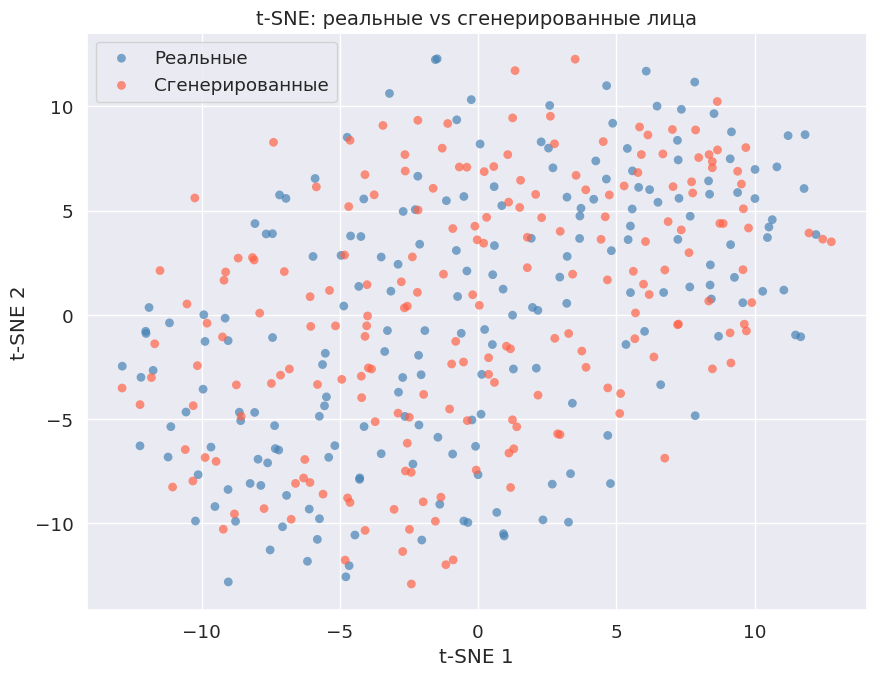

In [12]:
from sklearn.manifold import TSNE

VIS_N = 200

real_vis = real_flat[:VIS_N]
fake_vis = fake_flat[:VIS_N]
X_vis = np.vstack([real_vis, fake_vis])
y_vis = np.array([1] * VIS_N + [0] * VIS_N)

print(f"t-SNE на {X_vis.shape[0]} объектах размерности {X_vis.shape[1]}...")
tsne = TSNE(n_components=2, perplexity=30, n_iter=1000,
            init='pca', random_state=42, verbose=1)
X_2d = tsne.fit_transform(X_vis)

plt.figure(figsize=(9, 7))
plt.scatter(X_2d[y_vis == 1, 0], X_2d[y_vis == 1, 1],
            c='steelblue', label='Реальные',       s=40, alpha=0.7, edgecolors='none')
plt.scatter(X_2d[y_vis == 0, 0], X_2d[y_vis == 0, 1],
            c='tomato',    label='Сгенерированные', s=40, alpha=0.7, edgecolors='none')
plt.title('t-SNE: реальные vs сгенерированные лица', fontsize=14)
plt.xlabel('t-SNE 1'); plt.ylabel('t-SNE 2'); plt.legend()
plt.tight_layout(); plt.show()

Прокомментируйте получившийся результат:

**Комментарий:** Если облака точек **сильно перекрываются** — генератор хорошо приблизил распределение реальных лиц, и фейки попадают «внутрь» множества реальных. Если облака **чётко разделены** — между распределениями есть зазор: модель либо недообучена, либо есть mode collapse. Базовый DCGAN после 50 эпох обычно даёт **частичное перекрытие**: видны точки фейков в области реальных, но кое-где они образуют свой кластер — есть куда улучшать (увеличить число эпох, заменить архитектуру, добавить регуляризацию или перейти к StyleGAN).